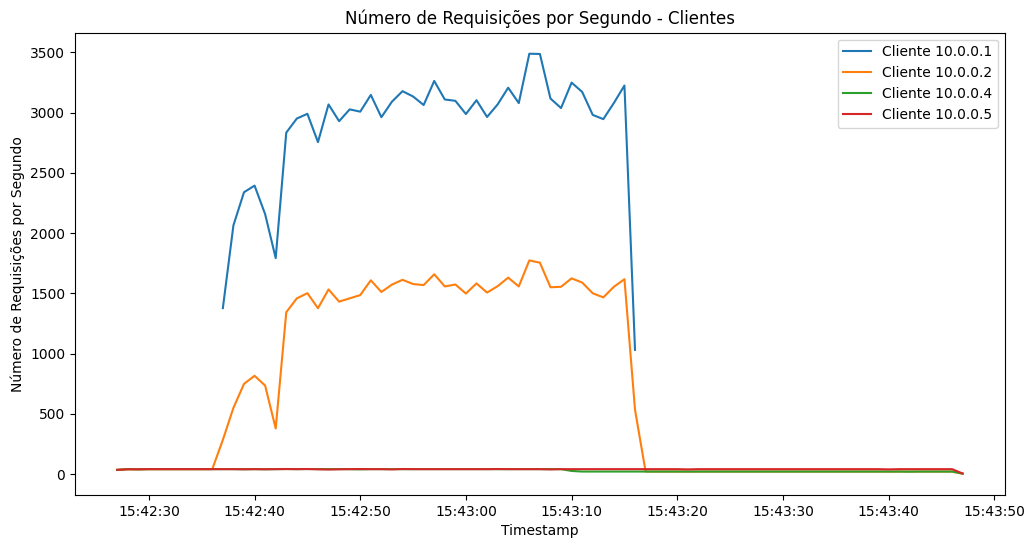

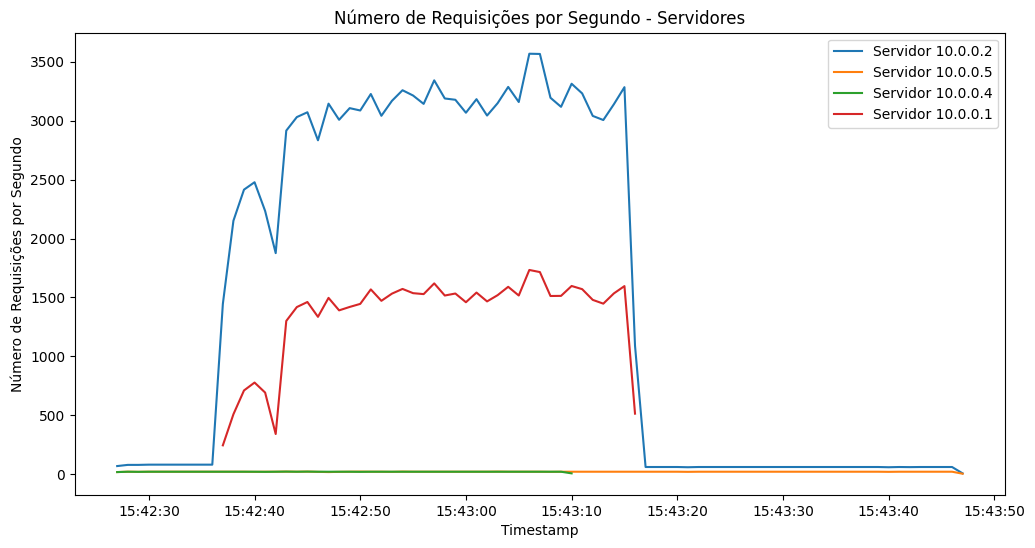

In [23]:
import pyshark
import matplotlib.pyplot as plt
from collections import defaultdict
import datetime
import nest_asyncio
import asyncio

# Permite rodar asyncio em Jupyter Notebook
nest_asyncio.apply()

# Listas com os caminhos dos arquivos .pcap dos clientes e servidores
clientes_pcap_files = ['Testes_Mininet/20-20-2000/cliente1.pcap', 'Testes_Mininet/20-20-2000/cliente2.pcap', 'Testes_Mininet/20-20-2000/cliente3.pcap']
servidores_pcap_files = ['Testes_Mininet/20-20-2000/servidor1.pcap', 'Testes_Mininet/20-20-2000/servidor2.pcap', 'Testes_Mininet/20-20-2000/servidor3.pcap']

# Inicializando dicionários para armazenar contagens de pacotes por segundo
clientes_data = defaultdict(lambda: defaultdict(int))
servidores_data = defaultdict(lambda: defaultdict(int))

async def process_pcap_file(file, data_dict, role):
    cap = pyshark.FileCapture(file, display_filter="tcp")

    # Processa cada pacote de forma síncrona
    for pkt in cap:
        try:
            # Extrair timestamp
            timestamp = datetime.datetime.fromtimestamp(float(pkt.sniff_timestamp))
            second_timestamp = timestamp.replace(microsecond=0)  # Arredonda para segundo inteiro
            
            # Determinar o IP relevante (origem para clientes e destino para servidores)
            ip = pkt.ip.src if role == 'cliente' else pkt.ip.dst
            data_dict[ip][second_timestamp] += 1  # Conta o pacote para o IP no segundo específico
        except AttributeError:
            # Ignora pacotes sem IP (ex.: ARP, etc.)
            continue
    
    cap.close()

async def run_processing():
    # Processa os pacotes dos clientes e servidores um de cada vez
    for file in clientes_pcap_files:
        await process_pcap_file(file, clientes_data, 'cliente')

    for file in servidores_pcap_files:
        await process_pcap_file(file, servidores_data, 'servidor')

# Função para plotar dados
def plot_data(data_dict, title, role):
    plt.figure(figsize=(12, 6))
    for ip, timestamps in data_dict.items():
        times = sorted(timestamps.keys())
        counts = [timestamps[time] for time in times]
        
        plt.plot(times, counts, label=f"{role} {ip}")
    
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Número de Requisições por Segundo")
    plt.legend()
    plt.grid()
    plt.show()

# Executa o processamento
await run_processing()

# Plota os dados dos clientes e servidores
plot_data(clientes_data, "Número de Requisições por Segundo - Clientes", "Cliente")
plot_data(servidores_data, "Número de Requisições por Segundo - Servidores", "Servidor")

/opt/homebrew/Cellar/python@3.12/3.12.7/Frameworks/Python.framework/Versions/3.12/lib/python3.12/subprocess.py:1887: RuntimeWarning: coroutine 'Capture._get_tshark_process' was never awaited
  close_fds, tuple(sorted(map(int, fds_to_keep))),


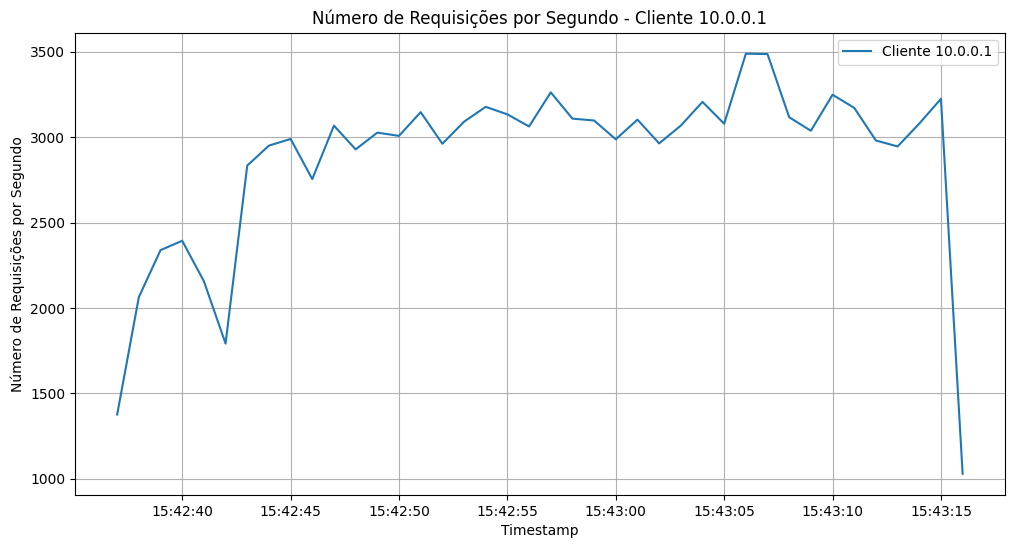

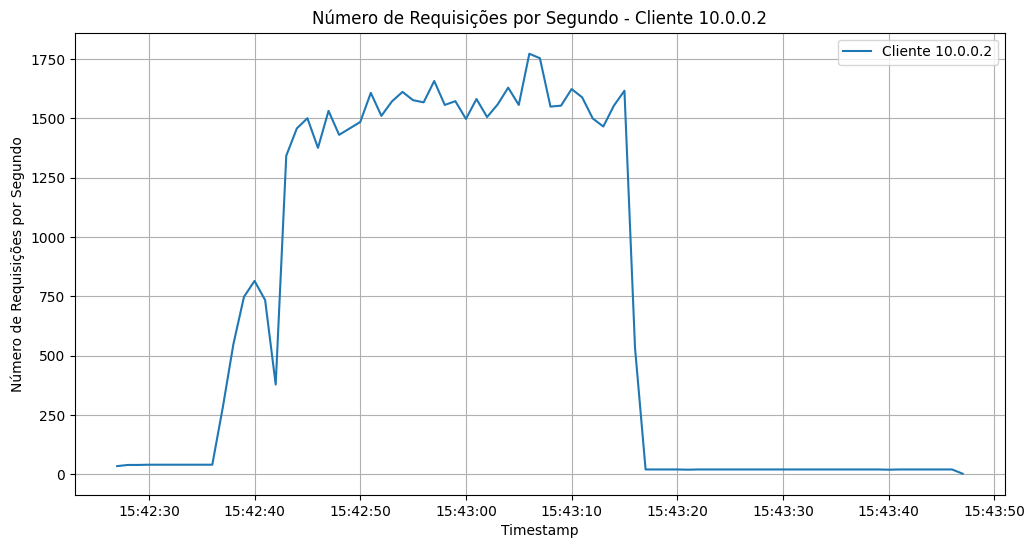

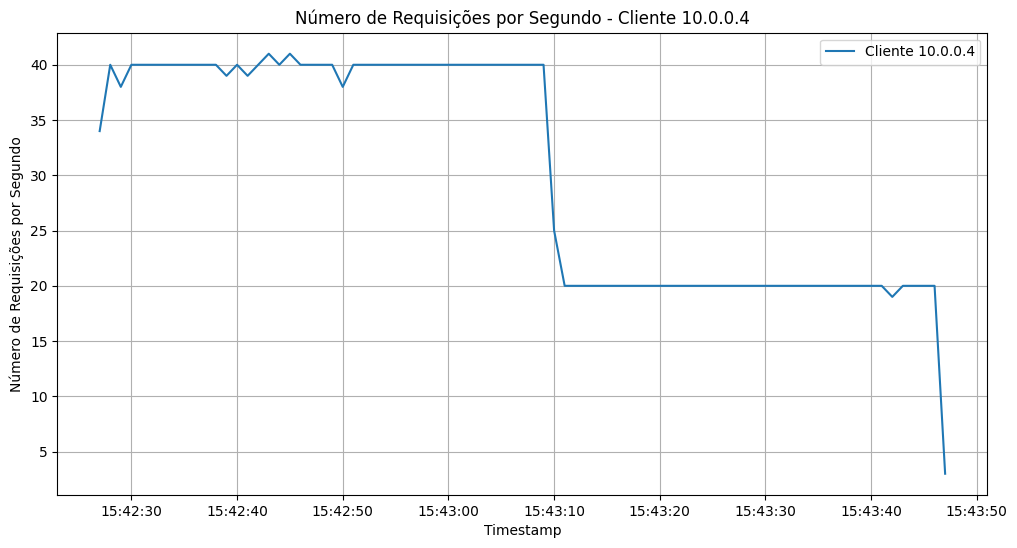

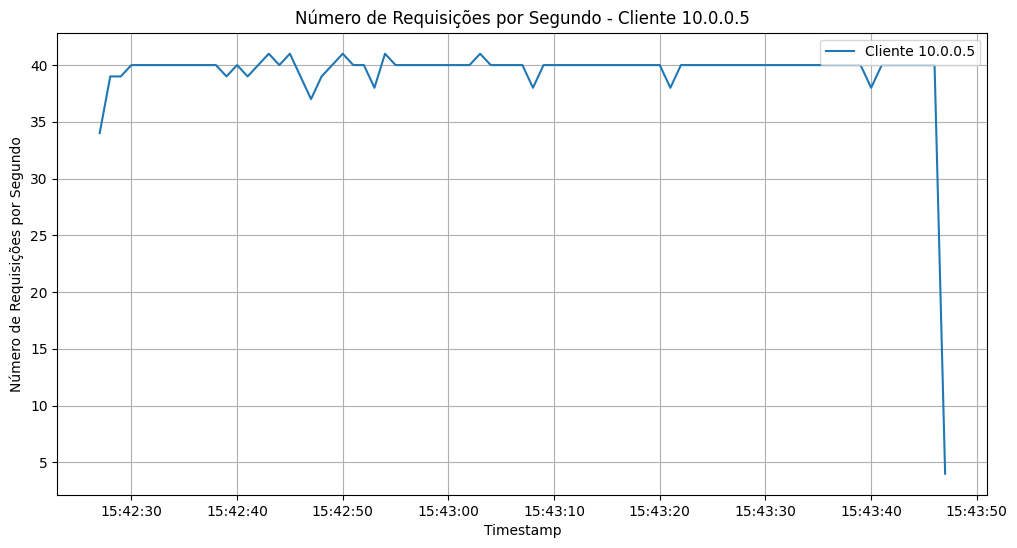

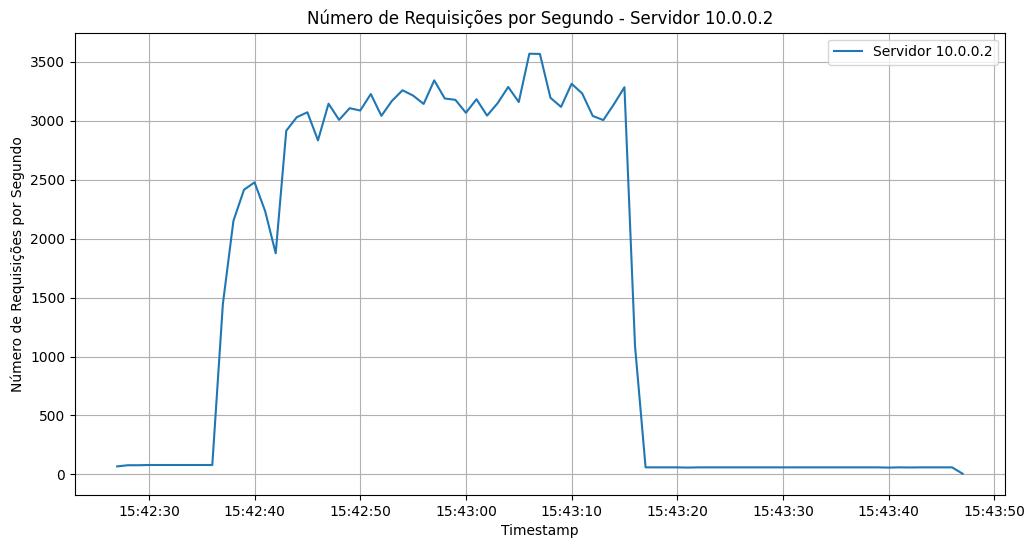

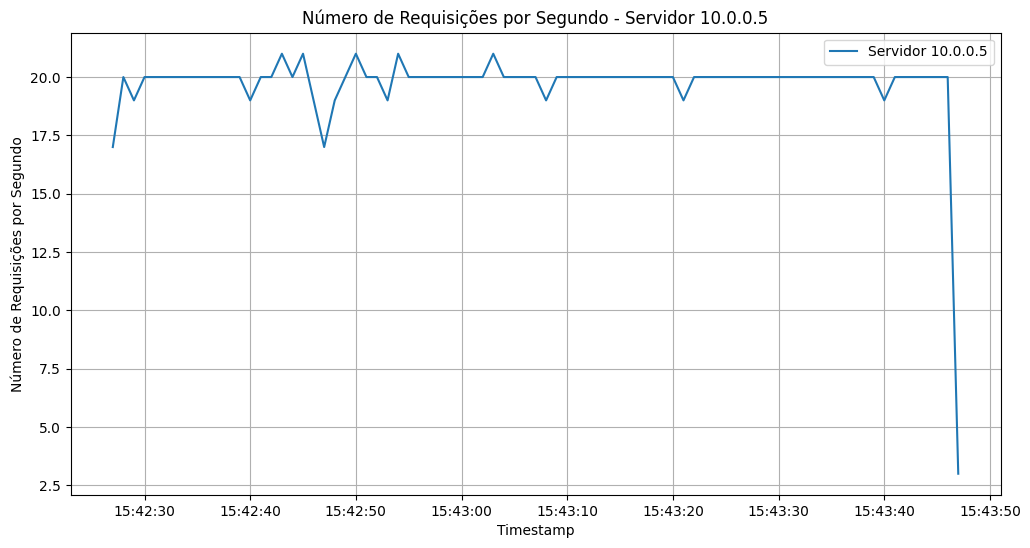

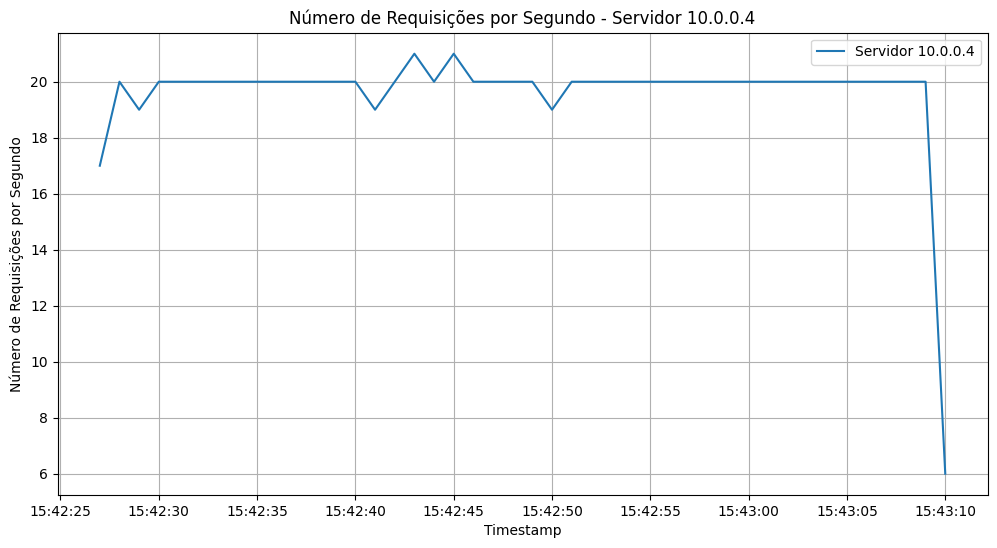

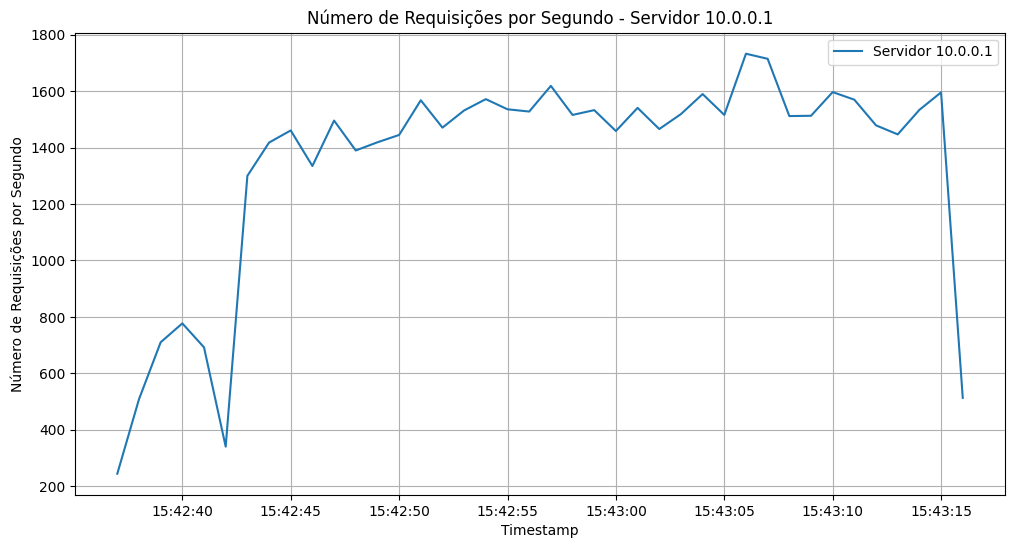

In [24]:
import pyshark
import matplotlib.pyplot as plt
from collections import defaultdict
import datetime
import nest_asyncio
import asyncio

# Permite rodar asyncio em Jupyter Notebook
nest_asyncio.apply()

# Listas com os caminhos dos arquivos .pcap dos clientes e servidores
clientes_pcap_files = ['Testes_Mininet/20-20-2000/cliente1.pcap', 'Testes_Mininet/20-20-2000/cliente2.pcap', 'Testes_Mininet/20-20-2000/cliente3.pcap']
servidores_pcap_files = ['Testes_Mininet/20-20-2000/servidor1.pcap', 'Testes_Mininet/20-20-2000/servidor2.pcap', 'Testes_Mininet/20-20-2000/servidor3.pcap']

# Inicializando dicionários para armazenar contagens de pacotes por segundo
clientes_data = defaultdict(lambda: defaultdict(int))
servidores_data = defaultdict(lambda: defaultdict(int))

async def process_pcap_file(file, data_dict, role):
    cap = pyshark.FileCapture(file, display_filter="tcp")

    # Processa cada pacote de forma síncrona
    for pkt in cap:
        try:
            # Extrair timestamp
            timestamp = datetime.datetime.fromtimestamp(float(pkt.sniff_timestamp))
            second_timestamp = timestamp.replace(microsecond=0)  # Arredonda para segundo inteiro
            
            # Determinar o IP relevante (origem para clientes e destino para servidores)
            ip = pkt.ip.src if role == 'cliente' else pkt.ip.dst
            data_dict[ip][second_timestamp] += 1  # Conta o pacote para o IP no segundo específico
        except AttributeError:
            # Ignora pacotes sem IP (ex.: ARP, etc.)
            continue
    
    cap.close()

async def run_processing():
    # Processa os pacotes dos clientes e servidores um de cada vez
    for file in clientes_pcap_files:
        await process_pcap_file(file, clientes_data, 'cliente')

    for file in servidores_pcap_files:
        await process_pcap_file(file, servidores_data, 'servidor')

# Função para plotar dados
def plot_data(data_dict, title, role):
    plt.figure(figsize=(12, 6))
    for ip, timestamps in data_dict.items():
        times = sorted(timestamps.keys())
        counts = [timestamps[time] for time in times]
        
        plt.plot(times, counts, label=f"{role} {ip}")
    
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Número de Requisições por Segundo")
    plt.legend()
    plt.grid()
    plt.show()

# Executa o processamento
await run_processing()

# Plota os dados dos clientes em gráficos separados
for ip in clientes_data.keys():
    plot_data({ip: clientes_data[ip]}, f"Número de Requisições por Segundo - Cliente {ip}", "Cliente")

# Plota os dados dos servidores em gráficos separados
for ip in servidores_data.keys():
    plot_data({ip: servidores_data[ip]}, f"Número de Requisições por Segundo - Servidor {ip}", "Servidor")


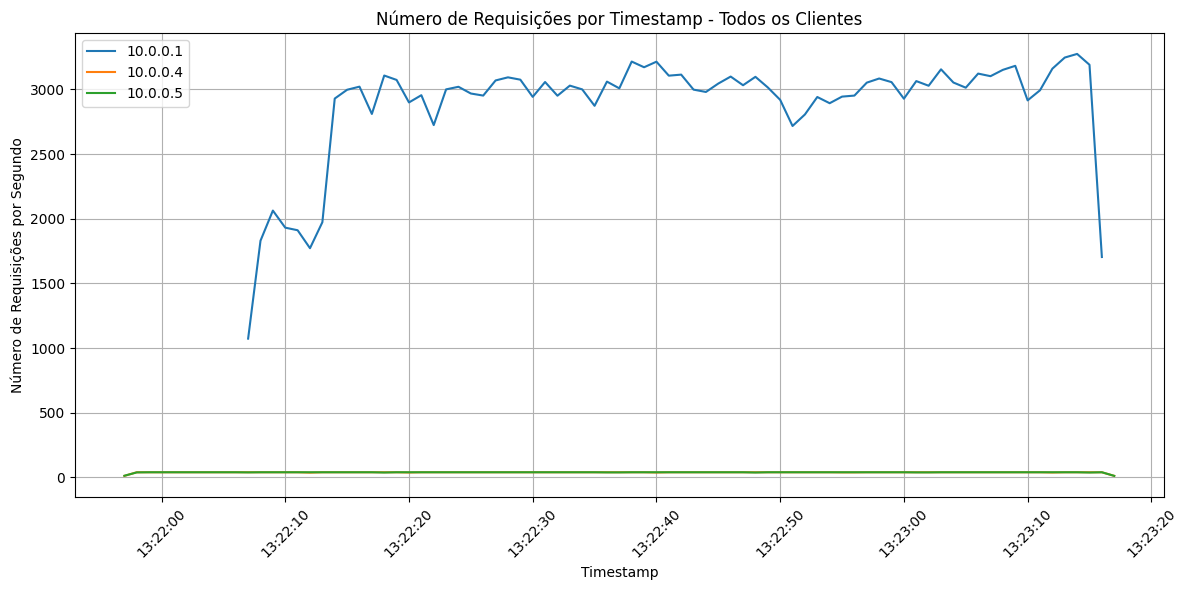

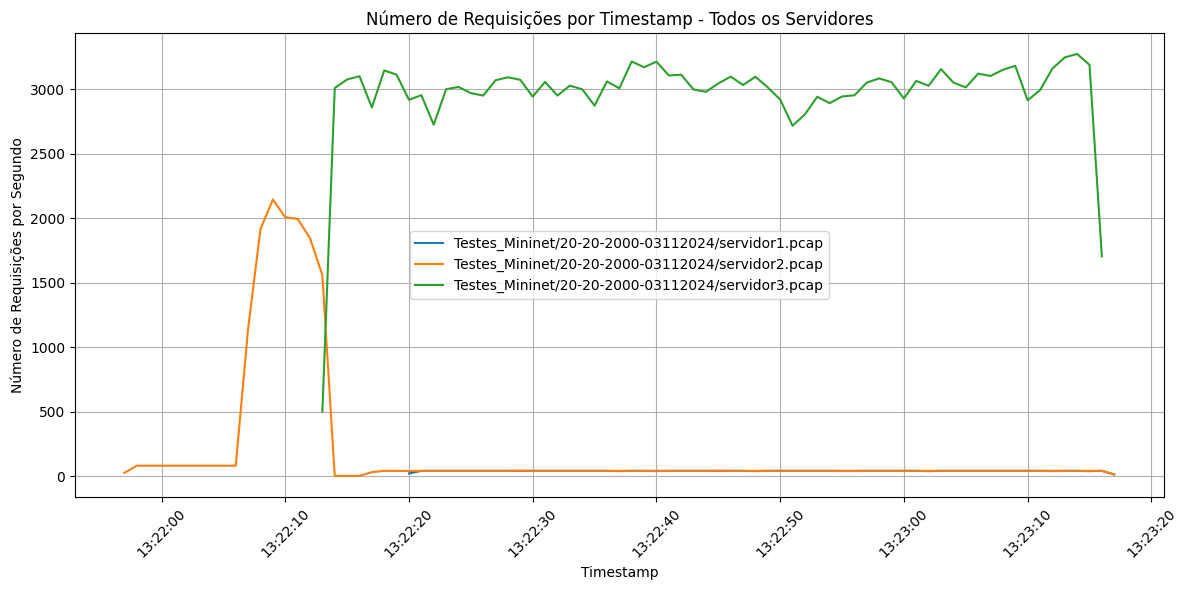

In [4]:
import pyshark
import matplotlib.pyplot as plt
from collections import defaultdict
import datetime
import nest_asyncio
import asyncio

# Permite rodar asyncio em Jupyter Notebook
nest_asyncio.apply()

# Listas com os caminhos dos arquivos .pcap dos clientes e servidores
clientes_pcap_files = ['Testes_Mininet/20-20-2000-03112024/cliente1.pcap','Testes_Mininet/20-20-2000-03112024/cliente2.pcap','Testes_Mininet/20-20-2000-03112024/cliente3.pcap']
servidores_pcap_files = ['Testes_Mininet/20-20-2000-03112024/servidor1.pcap','Testes_Mininet/20-20-2000-03112024/servidor2.pcap','Testes_Mininet/20-20-2000-03112024/servidor3.pcap']
#clientes_pcap_files = ['Testes_Mininet/20-20-2000-03112024/cliente2.pcap','Testes_Mininet/20-20-2000-03112024/cliente3.pcap']
#servidores_pcap_files = ['Testes_Mininet/20-20-2000-03112024/servidor1.pcap','Testes_Mininet/20-20-2000-03112024/servidor2.pcap']

# Inicializando dicionários para armazenar contagens de pacotes
clientes_data = defaultdict(lambda: defaultdict(int))
servidores_data = defaultdict(lambda: defaultdict(int))

# Mapeamento de IPs dos clientes
clientes_ips = {
    'Testes_Mininet/20-20-2000-03112024/cliente1.pcap': '10.0.0.1',
    'Testes_Mininet/20-20-2000-03112024/cliente2.pcap': '10.0.0.4',
    'Testes_Mininet/20-20-2000-03112024/cliente3.pcap': '10.0.0.5'
}

async def process_cliente_pcap(file, cliente_ip):
    cap = pyshark.FileCapture(file, display_filter="tcp.flags.syn == 1")
     
    # Processa cada pacote do cliente
    for pkt in cap:
        try:
            timestamp = datetime.datetime.fromtimestamp(float(pkt.sniff_timestamp))
            second_timestamp = timestamp.replace(microsecond=0)  # Arredonda para segundo inteiro
            
            if pkt.ip.src == cliente_ip:
                clientes_data[cliente_ip][second_timestamp] += 1
            if pkt.ip.dst == cliente_ip:
                clientes_data[cliente_ip][second_timestamp] += 1
                
        except AttributeError:
            continue
    
    cap.close()

async def process_servidor_pcap(file):
    #cap = pyshark.FileCapture(file, display_filter="tcp")
    cap = pyshark.FileCapture(file, display_filter="tcp.flags.syn == 1")
    
    # Processa cada pacote do servidor
    for pkt in cap:
        try:
            timestamp = datetime.datetime.fromtimestamp(float(pkt.sniff_timestamp))
            second_timestamp = timestamp.replace(microsecond=0)  # Arredonda para segundo inteiro
            
            # Pacotes recebidos pelo servidor
            servidores_data[file][second_timestamp] += 1
            
            # Pacotes respondidos (assumindo que são pacotes com a flag TCP ACK)
            if 'ACK' in pkt.tcp.flags:
                servidores_data[file][second_timestamp] += 1
        except AttributeError:
            continue
    
    cap.close()

async def run_processing():
    # Processa os pacotes dos clientes
    for file in clientes_pcap_files:
        cliente_ip = clientes_ips[file]  # Obtem o IP do cliente correspondente
        await process_cliente_pcap(file, cliente_ip)

    # Processa os pacotes dos servidores
    for file in servidores_pcap_files:
        await process_servidor_pcap(file)

# Função para plotar dados de todos os clientes ou servidores
def plot_data(data_dict, title, file_name):
    plt.figure(figsize=(12, 6))
    for ip, timestamps in data_dict.items():
        times = sorted(timestamps.keys())
        counts = [timestamps[time] for time in times]
        
        plt.plot(times, counts, label=f"{ip}")
    
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Número de Requisições por Segundo")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid()  # Adiciona grade ao gráfico
    plt.tight_layout()
    plt.savefig(file_name)
    plt.show()

# Executa o processamento
await run_processing()

# Plota os dados de todos os clientes em um único gráfico
plot_data(clientes_data, "Número de Requisições por Timestamp - Todos os Clientes", "num_req_cli.png")

# Plota os dados de todos os servidores em um único gráfico
plot_data(servidores_data, "Número de Requisições por Timestamp - Todos os Servidores", "num_req_serv.png")

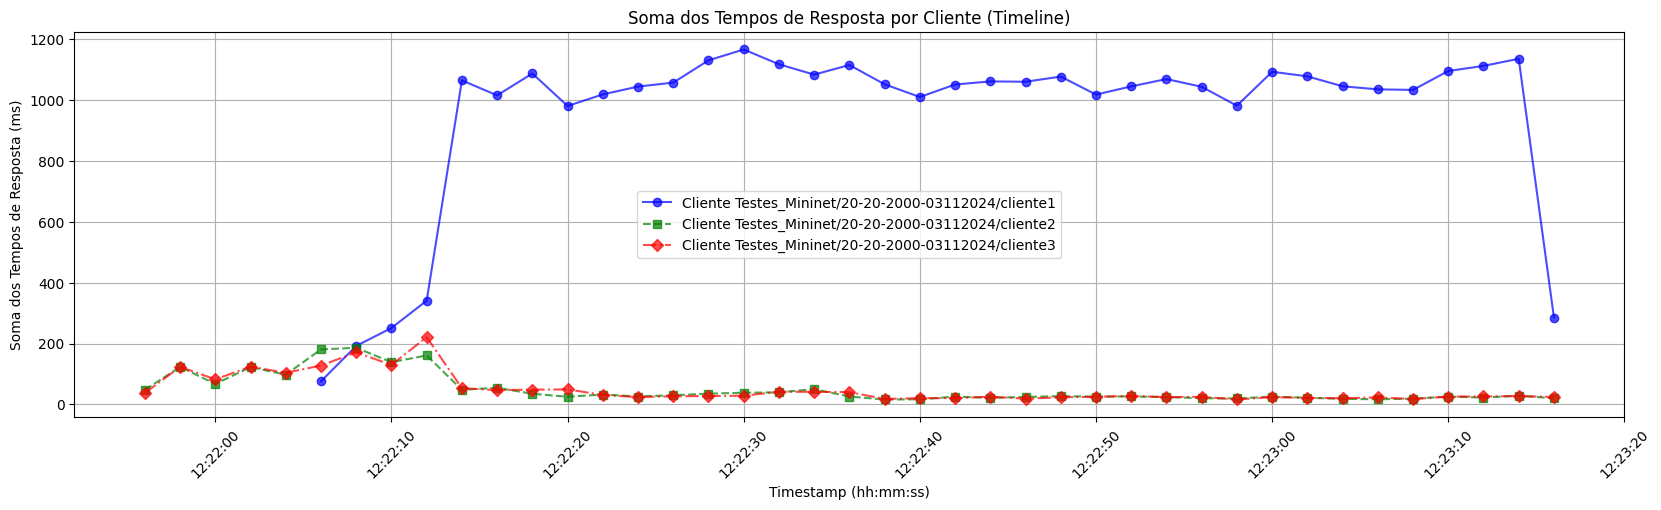

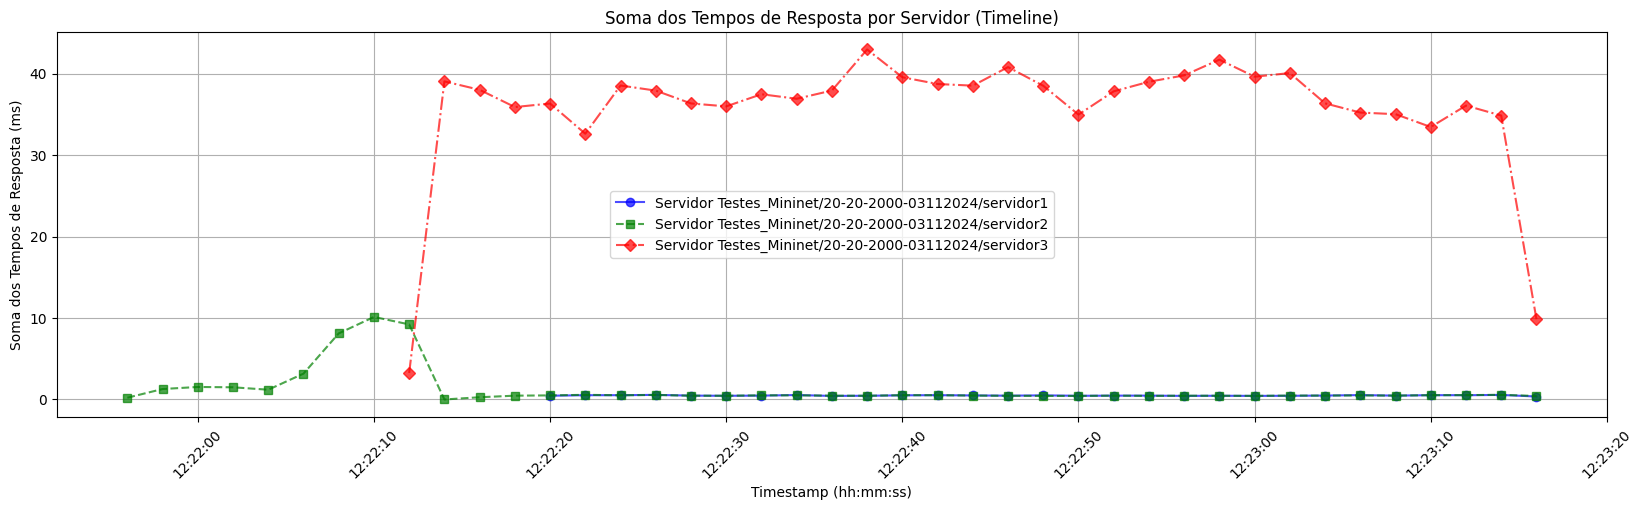

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from scapy.all import rdpcap, IP, TCP

# Função para calcular tempo de resposta entre SYN e SYN-ACK com nome do arquivo para identificação
def calculate_response_times(pcap_file, label):
    packets = rdpcap(pcap_file)
    response_times = []

    syn_requests = {}
    for pkt in packets:
        if pkt.haslayer(IP) and pkt.haslayer(TCP):
            src_ip = pkt[IP].src
            dst_ip = pkt[IP].dst
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
            tcp_layer = pkt[TCP]
            
            # Cria uma chave única para cada fluxo
            flow_key = (src_ip, dst_ip, src_port, dst_port)
            
            # Verifica se é um SYN
            if tcp_layer.flags == 'S':
                syn_requests[flow_key] = pkt.time
            
            # Verifica se é um SYN-ACK
            elif tcp_layer.flags == 'SA':
                reverse_flow_key = (dst_ip, src_ip, dst_port, src_port)
                if reverse_flow_key in syn_requests:
                    response_time = (pkt.time - syn_requests[reverse_flow_key]) * 1000
                    response_times.append({
                        'label': label,  # Nome do arquivo pcap como identificador
                        'tempo_resposta': float(response_time),
                        'timestamp': float(pkt.time)
                    })
                    # Remove o SYN para evitar duplicação
                    del syn_requests[reverse_flow_key]
                    
    return pd.DataFrame(response_times)

# Carrega os arquivos pcap para clientes e servidores
clientes_pcap = ['Testes_Mininet/20-20-2000-03112024/cliente1.pcap','Testes_Mininet/20-20-2000-03112024/cliente2.pcap','Testes_Mininet/20-20-2000-03112024/cliente3.pcap']
servidores_pcap = ['Testes_Mininet/20-20-2000-03112024/servidor1.pcap','Testes_Mininet/20-20-2000-03112024/servidor2.pcap','Testes_Mininet/20-20-2000-03112024/servidor3.pcap']

# Calcula tempos de resposta para cada pcap e concatena os dados
df_clientes = pd.concat([calculate_response_times(pcap, pcap.split('.')[0]) for pcap in clientes_pcap], ignore_index=True)
df_servidores = pd.concat([calculate_response_times(pcap, pcap.split('.')[0]) for pcap in servidores_pcap], ignore_index=True)

# Converte os timestamps para datetime e reamostra para alinhar os clientes em uma linha do tempo comum
df_clientes['timestamp'] = pd.to_datetime(df_clientes['timestamp'], unit='s')
df_servidores['timestamp'] = pd.to_datetime(df_servidores['timestamp'], unit='s')

# Define o intervalo de reamostragem e calcula a média por timestamp
df_clientes.set_index('timestamp', inplace=True)
df_servidores.set_index('timestamp', inplace=True)
df_clientes = df_clientes.groupby('label').resample('2s')['tempo_resposta'].sum().reset_index()
df_servidores = df_servidores.groupby('label').resample('2s')['tempo_resposta'].sum().reset_index()
#df_clientes = df_clientes.groupby('label').mean().reset_index()
#df_servidores = df_servidores.groupby('label').mean().reset_index()

# Cores e estilos para diferenciar as curvas
cores = ['b', 'g', 'r']
estilos_linha = ['-', '--', '-.']
marcadores = ['o', 's', 'D']
transparencia = 0.7

# Plota o tempo total de resposta por timestamp para cada cliente
plt.figure(figsize=(20, 5))
for i, (cliente, data) in enumerate(df_clientes.groupby("label")):
    plt.plot(data['timestamp'], data['tempo_resposta'], label=f"Cliente {cliente}",
             color=cores[i % len(cores)], linestyle=estilos_linha[i % len(estilos_linha)],
             marker=marcadores[i % len(marcadores)], alpha=transparencia)
plt.xlabel("Timestamp (hh:mm:ss)")
plt.ylabel("Soma dos Tempos de Resposta (ms)")
plt.title("Soma dos Tempos de Resposta por Cliente (Timeline)")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()

# Plota o tempo total de resposta por timestamp para cada servidor
plt.figure(figsize=(20, 5))
for i, (servidor, data) in enumerate(df_servidores.groupby("label")):
    plt.plot(data['timestamp'], data['tempo_resposta'], label=f"Servidor {servidor}",
             color=cores[i % len(cores)], linestyle=estilos_linha[i % len(estilos_linha)],
             marker=marcadores[i % len(marcadores)], alpha=transparencia)
plt.xlabel("Timestamp (hh:mm:ss)")
plt.ylabel("Soma dos Tempos de Resposta (ms)")
plt.title("Soma dos Tempos de Resposta por Servidor (Timeline)")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()


/var/folders/35/v1v1fk713f19bjkrvwjlb5mc0000gn/T/ipykernel_13596/3646948095.py:66: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_clientes_counts_resampled = df_clientes_counts.groupby([pd.Grouper(freq='1S'), 'label', 'tipo']).sum().unstack(fill_value=0)
/var/folders/35/v1v1fk713f19bjkrvwjlb5mc0000gn/T/ipykernel_13596/3646948095.py:67: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_servidores_counts_resampled = df_servidores_counts.groupby([pd.Grouper(freq='1S'), 'label', 'tipo']).sum().unstack(fill_value=0)


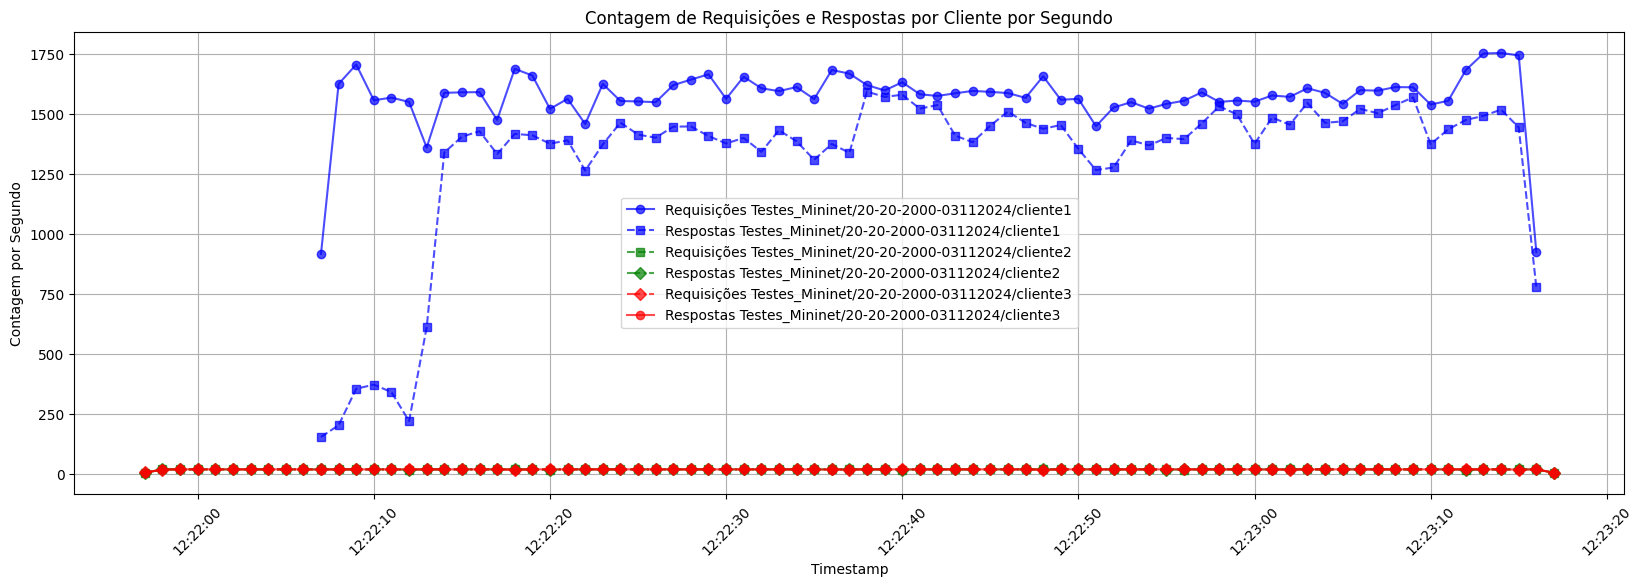

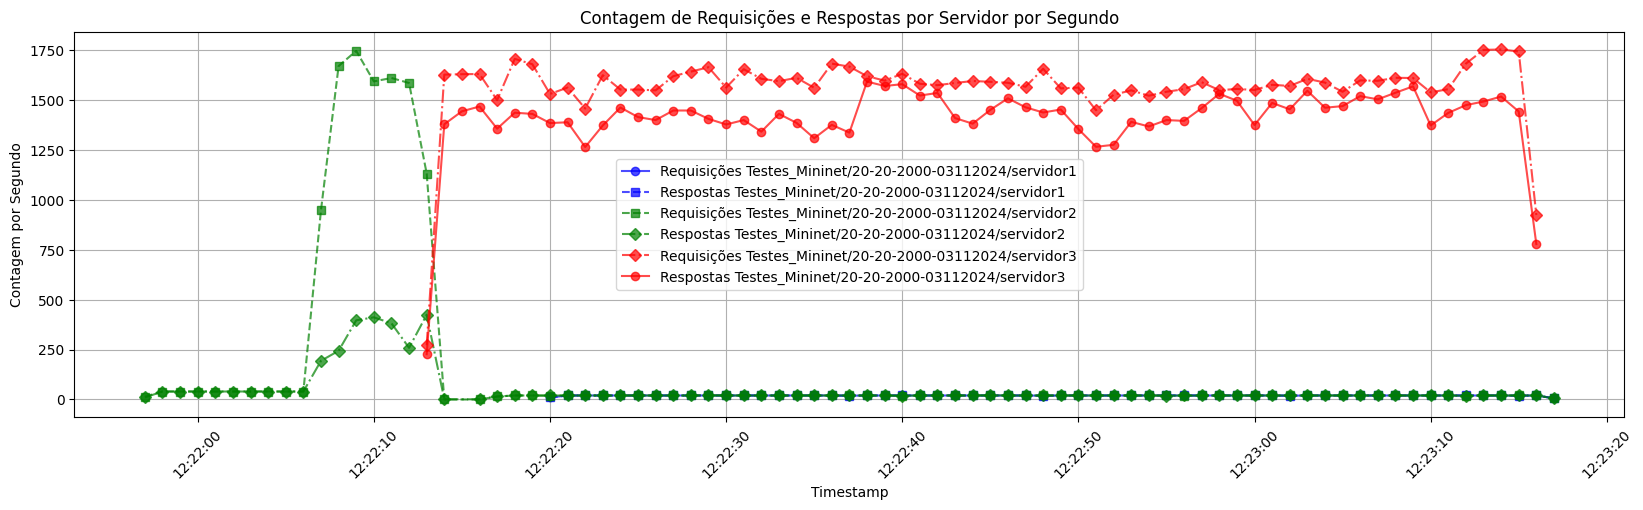

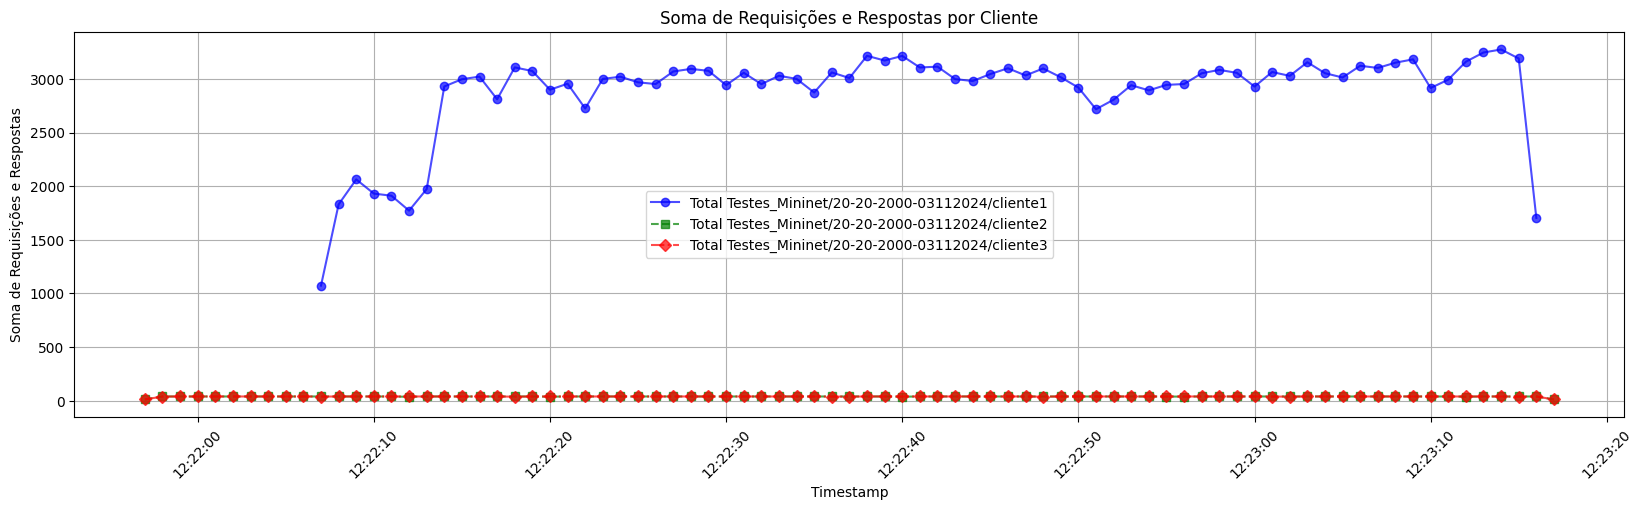

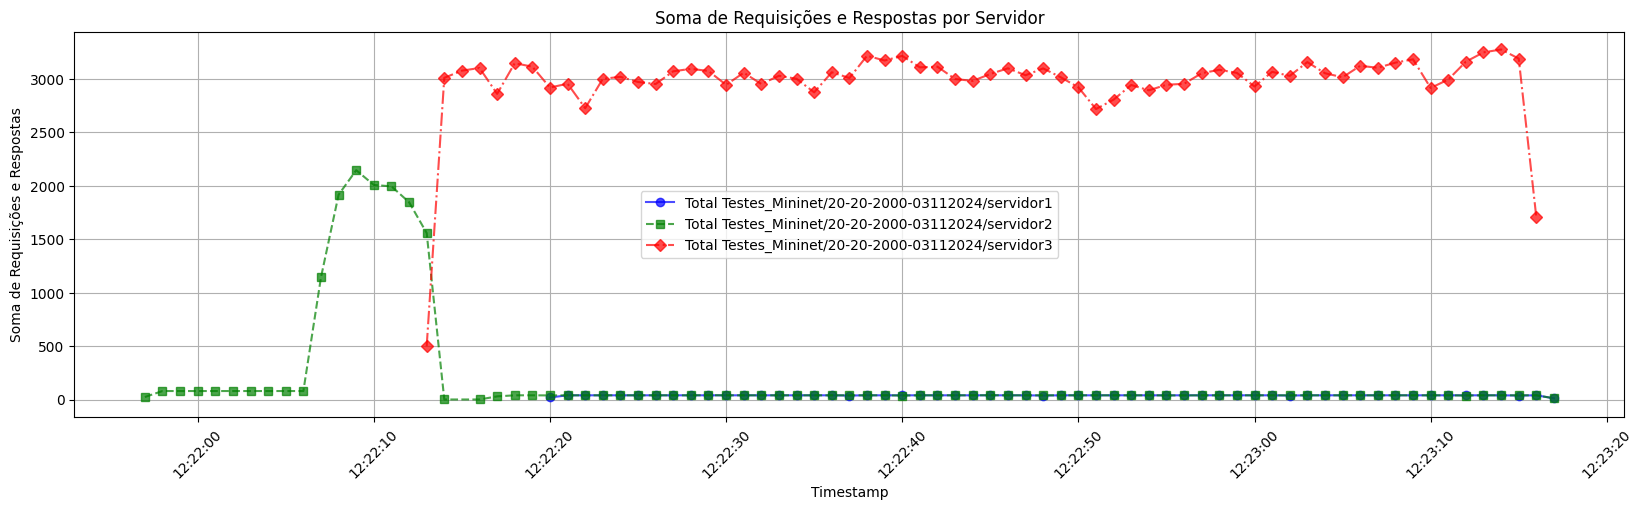

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from scapy.all import rdpcap, IP, TCP

# Função para contar pacotes SYN e SYN-ACK por segundo
def count_requests_responses_per_second(pcap_file, label):
    packets = rdpcap(pcap_file)
    request_counts = []
    response_counts = []
    
    for pkt in packets:
        if pkt.haslayer(IP) and pkt.haslayer(TCP):
            tcp_layer = pkt[TCP]
            timestamp = pkt.time  # Timestamp do pacote
            
            # Verifica se é um SYN para requisições
            if tcp_layer.flags == 'S':
                request_counts.append({
                    'label': label,  # Nome do arquivo pcap como identificador
                    'timestamp': float(timestamp),
                    'tipo': 'request',
                    'count': 1
                })
                
            # Verifica se é um SYN-ACK para respostas
            elif tcp_layer.flags == 'SA':
                response_counts.append({
                    'label': label,  # Nome do arquivo pcap como identificador
                    'timestamp': float(timestamp),
                    'tipo': 'response',
                    'count': 1
                })
    
    # Converte para DataFrames
    df_requests = pd.DataFrame(request_counts)
    df_responses = pd.DataFrame(response_counts)
    
    # Concatena requisições e respostas para análise conjunta
    return pd.concat([df_requests, df_responses], ignore_index=True)

# Carrega os arquivos pcap para clientes e servidores
clientes_pcap = ['Testes_Mininet/20-20-2000-03112024/cliente1.pcap','Testes_Mininet/20-20-2000-03112024/cliente2.pcap','Testes_Mininet/20-20-2000-03112024/cliente3.pcap']
servidores_pcap = ['Testes_Mininet/20-20-2000-03112024/servidor1.pcap','Testes_Mininet/20-20-2000-03112024/servidor2.pcap','Testes_Mininet/20-20-2000-03112024/servidor3.pcap']

# Conta requisições e respostas para cada pcap e concatena os dados
df_clientes_counts = pd.concat([count_requests_responses_per_second(pcap, pcap.split('.')[0]) for pcap in clientes_pcap], ignore_index=True)
df_servidores_counts = pd.concat([count_requests_responses_per_second(pcap, pcap.split('.')[0]) for pcap in servidores_pcap], ignore_index=True)

# Converte os timestamps para datetime
df_clientes_counts['timestamp'] = pd.to_datetime(df_clientes_counts['timestamp'], unit='s')
df_servidores_counts['timestamp'] = pd.to_datetime(df_servidores_counts['timestamp'], unit='s')

# Agrupa as requisições e respostas por segundo
df_clientes_counts.set_index('timestamp', inplace=True)
df_servidores_counts.set_index('timestamp', inplace=True)

# Contagem por segundo
df_clientes_counted = df_clientes_counts.groupby([pd.Grouper(freq='1s'), 'label', 'tipo']).sum().unstack(fill_value=0)
df_servidores_counted = df_servidores_counts.groupby([pd.Grouper(freq='1s'), 'label', 'tipo']).sum().unstack(fill_value=0)

# Resetando os índices para facilitar o acesso aos dados
df_clientes_counted.reset_index(inplace=True)
df_servidores_counted.reset_index(inplace=True)

# Soma as requisições e respostas para cada timestamp
df_clientes_counts_resampled = df_clientes_counts.groupby([pd.Grouper(freq='1s'), 'label', 'tipo']).sum().unstack(fill_value=0)
df_servidores_counts_resampled = df_servidores_counts.groupby([pd.Grouper(freq='1s'), 'label', 'tipo']).sum().unstack(fill_value=0)

# Resetando os índices para facilitar o acesso aos dados
df_clientes_counts_resampled.reset_index(inplace=True)
df_servidores_counts_resampled.reset_index(inplace=True)

# Contagem das requisições e respostas por timestamp
df_clientes_counts_resampled['total'] = df_clientes_counts_resampled[('count', 'request')] + df_clientes_counts_resampled[('count', 'response')]
df_servidores_counts_resampled['total'] = df_servidores_counts_resampled[('count', 'request')] + df_servidores_counts_resampled[('count', 'response')]

# Cores e estilos para diferenciar as curvas
cores = ['b', 'g', 'r']
estilos_linha = ['-', '--', '-.']
marcadores = ['o', 's', 'D']
transparencia = 0.7

# Plota o número de requisições e respostas por segundo para cada cliente
plt.figure(figsize=(20, 6))
for i, (cliente, data) in enumerate(df_clientes_counted.groupby("label")):
    # Acessando as contagens de requisições e respostas
    plt.plot(data['timestamp'], data[('count', 'request')], label=f"Requisições {cliente}",
             color=cores[i % len(cores)], linestyle=estilos_linha[i % len(estilos_linha)],
             marker=marcadores[i % len(marcadores)], alpha=transparencia)
    plt.plot(data['timestamp'], data[('count', 'response')], label=f"Respostas {cliente}",
             color=cores[i % len(cores)], linestyle=estilos_linha[(i + 1) % len(estilos_linha)],
             marker=marcadores[(i + 1) % len(marcadores)], alpha=transparencia)
plt.xlabel("Timestamp")
plt.ylabel("Contagem por Segundo")
plt.title("Contagem de Requisições e Respostas por Cliente por Segundo")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()

# Plota o número de requisições e respostas por segundo para cada servidor
plt.figure(figsize=(20, 5))
for i, (servidor, data) in enumerate(df_servidores_counted.groupby("label")):
    # Acessando as contagens de requisições e respostas
    plt.plot(data['timestamp'], data[('count', 'request')], label=f"Requisições {servidor}",
             color=cores[i % len(cores)], linestyle=estilos_linha[i % len(estilos_linha)],
             marker=marcadores[i % len(marcadores)], alpha=transparencia)
    plt.plot(data['timestamp'], data[('count', 'response')], label=f"Respostas {servidor}",
             color=cores[i % len(cores)], linestyle=estilos_linha[(i + 1) % len(estilos_linha)],
             marker=marcadores[(i + 1) % len(marcadores)], alpha=transparencia)
plt.xlabel("Timestamp")
plt.ylabel("Contagem por Segundo")
plt.title("Contagem de Requisições e Respostas por Servidor por Segundo")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()

# Plotando a soma total de requisições e respostas por cliente
plt.figure(figsize=(20, 5))
for i, (cliente, data) in enumerate(df_clientes_counts_resampled.groupby("label")):
    plt.plot(data['timestamp'], data['total'], label=f"Total {cliente}",
             color=cores[i % len(cores)], linestyle=estilos_linha[i % len(estilos_linha)],
             marker=marcadores[i % len(marcadores)], alpha=transparencia)
plt.xlabel("Timestamp")
plt.ylabel("Soma de Requisições e Respostas")
plt.title("Soma de Requisições e Respostas por Cliente")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()

# Plotando a soma total de requisições e respostas por servidor
plt.figure(figsize=(20,5))
for i, (servidor, data) in enumerate(df_servidores_counts_resampled.groupby("label")):
    plt.plot(data['timestamp'], data['total'], label=f"Total {servidor}",
             color=cores[i % len(cores)], linestyle=estilos_linha[i % len(estilos_linha)],
             marker=marcadores[i % len(marcadores)], alpha=transparencia)
plt.xlabel("Timestamp")
plt.ylabel("Soma de Requisições e Respostas")
plt.title("Soma de Requisições e Respostas por Servidor")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()